# Chapter 6: Construction Problems and Field Extensions

**Source span.** Hartshorne, *Geometry: Euclid and Beyond*, Chapter 6, printed pp. 241-294 / PDF pp. 253-306, Sections 28-32.

**Guiding question.** Which geometric construction requests are really requests to enter a larger field, and which requests fail because the required field has the wrong algebraic shape?

**Chapter goal.** Build a visual and computational ledger for the chapter's boundary line: straightedge-compass constructions climb by quadratic extensions, marked-ruler constructions add cubic and quartic gates, and regular polygons reveal the same field-degree tests in the roots of unity.

## Computational Translation Guide

| Book language | Notebook model |
| --- | --- |
| constructible number | a real coordinate reached by field operations and square-root adjunctions |
| tower of fields | a directed dependency graph with edge labels equal to extension degrees |
| impossible classical problem | a required coordinate whose minimal polynomial or transcendence blocks the permitted tower |
| regular `n`-gon | the real part of an `n`th root of unity, checked through `2*cos(2*pi/n)` |
| marked ruler / neusis | an added operation equivalent to a conchoid-line intersection, hence a quartic equation |
| cubic and quartic solution | a route through square roots, cube roots, angle trisection, and the cubic resolvent |
| finite extension degree | vector-space dimension, validated by multiplicativity and minimal polynomials |

## Route Through The Chapter

1. Use Section 28 to turn the three famous problems into degree and algebraicity tests.
2. Use Section 29 to inspect why the regular 17-gon is a positive example: the real cyclotomic data descends through repeated quadratic choices.
3. Use Section 30 to compare the marked ruler with straightedge-compass operations by drawing the conchoid hidden inside a neusis step.
4. Use Section 31 to connect real cubic and quartic equations to the marked-ruler operation.
5. Use Section 32 as the algebra ledger: degrees multiply, roots generate extensions, and a Galois-group check is sharper than degree alone.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from sympy.polys.numberfields import galois_group


def find_book_root() -> Path:
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in (base, base / "Euclid-and-Beyond"):
            if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
                return candidate
    raise FileNotFoundError("Could not locate the Euclid-and-Beyond book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.plotting import draw_segment, label_point

UNIT = "chapter-06"
CHAPTER_DIR = BOOK_ROOT / "chapter-06-construction-problems-and-field-extensions"
NOTEBOOK_PATH = CHAPTER_DIR / "06-construction-problems-and-field-extensions.ipynb"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIG_DIR = UNIT_ARTIFACT_ROOT / "figures"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR, INTERACTIVE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ARTIFACTS: list[Path] = []
CHECKS: dict[str, dict] = {}


def remember(path: str | Path) -> Path:
    path = Path(path)
    ARTIFACTS.append(path)
    return path


def book_relative(path: str | Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def write_table(df: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return remember(path)


def is_power_of(value: int, allowed_primes: set[int]) -> bool:
    if value < 1:
        return False
    remaining = int(value)
    for prime in sorted(allowed_primes):
        while remaining % prime == 0 and remaining > 1:
            remaining //= prime
    return remaining == 1


def style_axis(ax, title: str | None = None) -> None:
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e5e7eb", linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color("#cbd5e1")
    if title:
        ax.set_title(title, loc="left", fontsize=12, weight="bold")


## Visual Storyboard And Library Routing

The chapter is algebraic, but the visuals are not decorative algebra posters. Each one exposes a different inspection target.

| Concept | Representation | Library choice | What to inspect | Check |
| --- | --- | --- | --- | --- |
| straightedge-compass limit | field-tower graph plus obstruction ledger | Matplotlib, NetworkX, SymPy | every compass step is a degree-2 gate; degree 3 and transcendence block famous requests | irreducible cubics, pi transcendence flag, degree powers |
| regular 17-gon | roots-of-unity period layers | Matplotlib, SymPy | the 17 vertices are easy to draw; the field signal is the nested period partition | side-length spread, period residuals, minimal polynomial degree 8 |
| marked ruler | conchoid hidden in a neusis step | Matplotlib, SymPy | sliding a marked segment between two lines is a quartic intersection problem | conchoid residual, quartic degree, distance residual |
| cubic/quartic equations | route graph and symbolic identities | NetworkX, SymPy | Cardano, trisection, and the cubic resolvent are operations in the same construction route | exact polynomial identities |
| finite extensions | degree ledger and constructibility table | NetworkX, SymPy, pandas | degree alone is necessary but not always sufficient; Galois order sharpens the test | degree multiplication, minpoly degrees, Galois order |
| applied lab | regular `n`-gon filter | Plotly, pandas | compare compass-only polygons with marked-ruler-only polygons | Euler phi factor tests |


## 1. The Quadratic Gate And The Three Famous Problems

Section 28 translates a construction into a coordinate-field statement. Starting from rational data, a straightedge-compass construction can use field arithmetic and square roots. This means every successful coordinate lies in a tower whose nontrivial steps have degree 2, so the degree of the generated field over `Q` must be a power of 2.

That necessary condition immediately catches two classical failures. Duplicating the cube asks for `cuberoot(2)`, whose minimal polynomial has degree 3. Trisecting a 60 degree angle asks for `2*cos(20 degrees)`, a root of `x^3 - 3*x - 1`, again degree 3. Squaring the circle is different: the obstruction is not merely the wrong finite degree, but the transcendence of `pi`, an analytic theorem the chapter invokes rather than proves.

Inspect the diagram as a gate ledger. Blue arrows are allowed by compass and straightedge. Red requests ask for coordinates outside that quadratic tower.


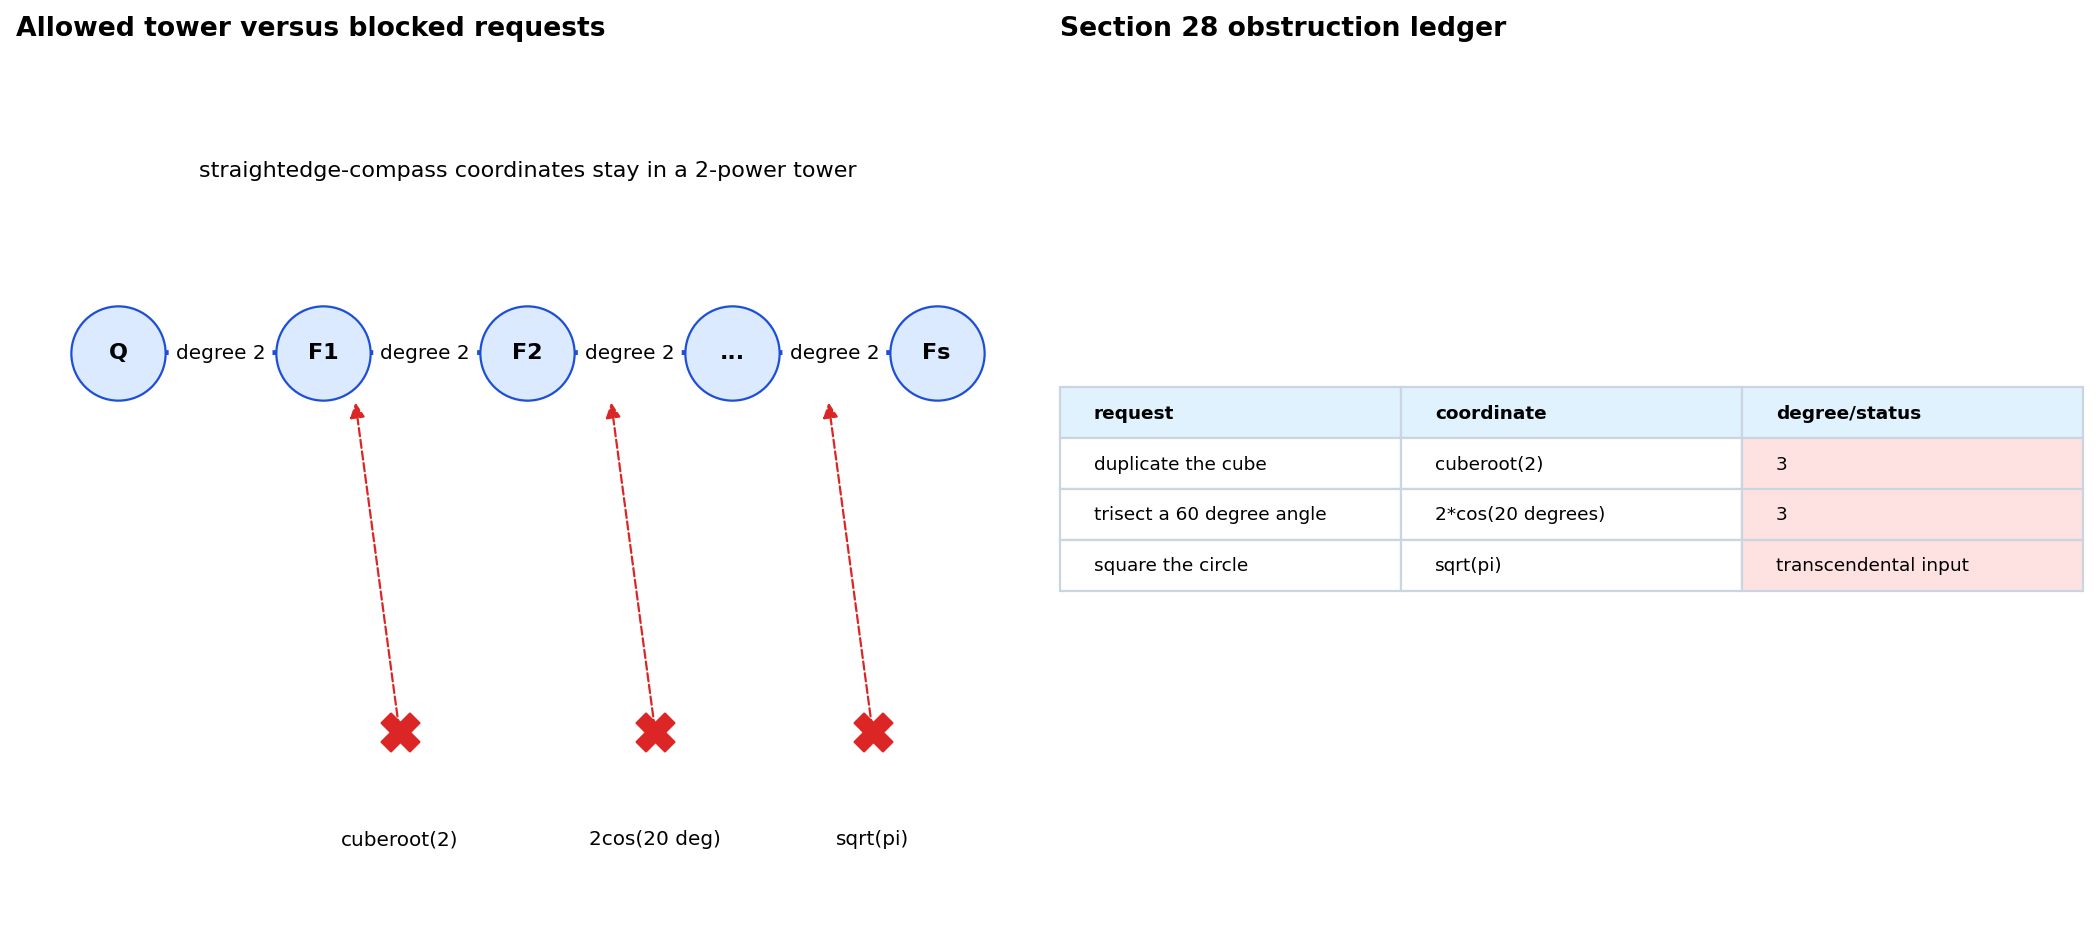

,problem,required_coordinate,polynomial,irreducible_over_Q,degree_or_status,straightedge_compass_status
0,duplicate the cube,cuberoot(2),x**3 - 2,True,3,blocked: degree is not a power of 2
1,trisect a 60 degree angle,2*cos(20 degrees),x**3 - 3*x - 1,True,3,blocked: degree is not a power of 2
2,square the circle,sqrt(pi),none over Q for pi,None,transcendental input,blocked by transcendence of pi


In [2]:
x = sp.symbols("x")

cube_poly = sp.Poly(x**3 - 2, x, domain=sp.QQ)
trisection_poly = sp.Poly(x**3 - 3 * x - 1, x, domain=sp.QQ)
cos20_poly = sp.Poly(8 * x**3 - 6 * x - 1, x, domain=sp.QQ)

obstruction_table = pd.DataFrame([
    {
        "problem": "duplicate the cube",
        "required_coordinate": "cuberoot(2)",
        "polynomial": str(cube_poly.as_expr()),
        "irreducible_over_Q": bool(cube_poly.is_irreducible),
        "degree_or_status": cube_poly.degree(),
        "straightedge_compass_status": "blocked: degree is not a power of 2",
    },
    {
        "problem": "trisect a 60 degree angle",
        "required_coordinate": "2*cos(20 degrees)",
        "polynomial": str(trisection_poly.as_expr()),
        "irreducible_over_Q": bool(trisection_poly.is_irreducible),
        "degree_or_status": trisection_poly.degree(),
        "straightedge_compass_status": "blocked: degree is not a power of 2",
    },
    {
        "problem": "square the circle",
        "required_coordinate": "sqrt(pi)",
        "polynomial": "none over Q for pi",
        "irreducible_over_Q": None,
        "degree_or_status": "transcendental input",
        "straightedge_compass_status": "blocked by transcendence of pi",
    },
])
obstruction_table_path = write_table(obstruction_table, "degree-obstructions.csv")

construction_checks = {
    "cube_poly_irreducible": bool(cube_poly.is_irreducible),
    "cube_degree": cube_poly.degree(),
    "trisection_poly_irreducible": bool(trisection_poly.is_irreducible),
    "trisection_degree": trisection_poly.degree(),
    "cos20_scaled_poly_irreducible": bool(cos20_poly.is_irreducible),
    "cos20_degree": cos20_poly.degree(),
    "pi_transcendental_known_to_sympy": bool(sp.pi.is_transcendental),
    "degree_3_is_power_of_2": is_power_of(3, {2}),
}
CHECKS["construction_degree_gates"] = construction_checks
construction_checks_path = remember(save_json(construction_checks, UNIT, "checks", "degree-obstructions.json", root=ARTIFACT_ROOT))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), constrained_layout=True)
ax = axes[0]
G = nx.DiGraph()
G.add_edges_from([("Q", "F1"), ("F1", "F2"), ("F2", "..."), ("...", "Fs")])
pos = {"Q": (0, 0), "F1": (1.6, 0), "F2": (3.2, 0), "...": (4.8, 0), "Fs": (6.4, 0)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#dbeafe", edgecolors="#1d4ed8", node_size=1800)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=2.2, edge_color="#1d4ed8")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): "degree 2" for u, v in G.edges}, ax=ax, font_size=9)
blocked = {"cuberoot(2)": (2.2, -1.25), "2cos(20 deg)": (4.2, -1.25), "sqrt(pi)": (5.9, -1.25)}
for label, point in blocked.items():
    ax.scatter([point[0]], [point[1]], s=290, marker="X", color="#dc2626", zorder=4)
    ax.text(point[0], point[1] - 0.32, label, ha="center", va="top", fontsize=9)
    ax.add_patch(FancyArrowPatch(point, (point[0] - 0.35, -0.15), arrowstyle="-|>", mutation_scale=14, color="#dc2626", linestyle="--"))
ax.text(3.2, 0.58, "straightedge-compass coordinates stay in a 2-power tower", ha="center", fontsize=10)
ax.set_xlim(-0.8, 7.2)
ax.set_ylim(-1.9, 1.0)
ax.axis("off")
ax.set_title("Allowed tower versus blocked requests", loc="left", fontsize=12, weight="bold")

ax = axes[1]
ax.axis("off")
cell_text = obstruction_table[["problem", "required_coordinate", "degree_or_status"]].values.tolist()
table = ax.table(cellText=cell_text, colLabels=["request", "coordinate", "degree/status"], cellLoc="left", colLoc="left", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(8.3)
table.scale(1, 1.55)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#cbd5e1")
    if row == 0:
        cell.set_facecolor("#e0f2fe")
        cell.set_text_props(weight="bold")
    elif col == 2:
        cell.set_facecolor("#fee2e2")
ax.set_title("Section 28 obstruction ledger", loc="left", fontsize=12, weight="bold")

construction_path = remember(save_matplotlib(fig, UNIT, "figures", "construction-degree-gates.png", root=ARTIFACT_ROOT))
plt.close(fig)

display_artifact(construction_path, width=980)
obstruction_table


The table is intentionally only a necessary-condition ledger. Section 28 later warns that a power-of-2 degree by itself is not enough; the splitting field and its Galois group matter. The final section returns to that sharper test with a quartic example.


## 2. The Regular 17-gon Signal

Section 29 gives a positive result that looks surprising next to the impossible problems. A regular `n`-gon is controlled by a root of unity. For `n = 17`, the real coordinate `2*cos(2*pi/17)` has degree 8 over `Q`, and the Gauss-period calculation splits that degree into three quadratic decisions.

The figure below draws all 17 roots, but the inspection target is the color hierarchy. The powers in the larger blue period sum to `(-1 + sqrt(17))/2`; the orange subperiod is then quadratic over that; the final red pair contains `zeta + zeta^{-1} = 2*cos(2*pi/17)`. The geometry becomes constructible because each descent is quadratic.


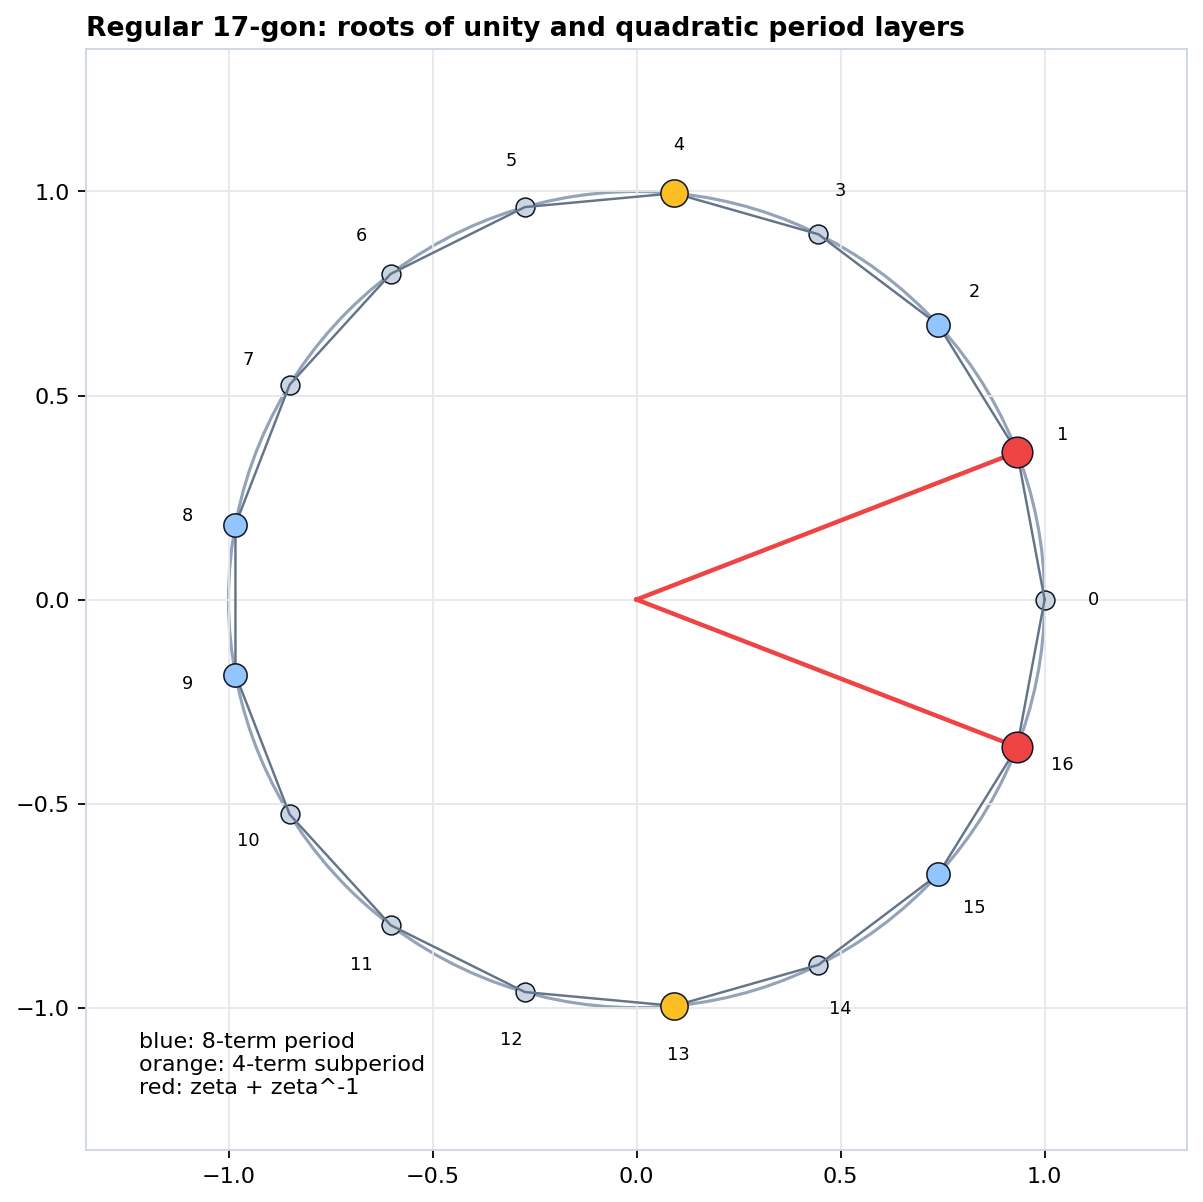

,period,exponents,numeric_sum,check
0,8-term gamma,"[1, 2, 4, 8, 16, 15, 13, 9]",1.561553,quadratic over Q
1,4-term beta,"[1, 4, 13, 16]",2.049481,root of t^2 - gamma*t - 1
2,2-term alpha,"[1, 16]",1.864944,"2*cos(2*pi/17), degree 8 over Q"


In [3]:
n = 17
angles = 2 * np.pi * np.arange(n) / n
roots = np.column_stack([np.cos(angles), np.sin(angles)])
period_8 = [1, 2, 4, 8, 16, 15, 13, 9]
period_4 = [1, 4, 13, 16]
period_2 = [1, 16]
period_4_complement = [2, 8, 9, 15]
zeta = np.exp(2j * np.pi / n)

gamma_numeric = sum(zeta**k for k in period_8).real
beta_numeric = sum(zeta**k for k in period_4).real
beta_prime_numeric = sum(zeta**k for k in period_4_complement).real
alpha_numeric = sum(zeta**k for k in period_2).real
side_lengths_17 = np.linalg.norm(np.roll(roots, -1, axis=0) - roots, axis=1)
alpha_minpoly = sp.Poly(sp.minpoly(2 * sp.cos(2 * sp.pi / 17), x), x)
gamma_exact = (-1 + sp.sqrt(17)) / 2

seventeen_checks = {
    "period_8_exponents": period_8,
    "period_4_exponents": period_4,
    "period_2_exponents": period_2,
    "gamma_numeric": float(gamma_numeric),
    "gamma_exact": str(gamma_exact),
    "gamma_residual": float(abs(gamma_numeric - float(gamma_exact.evalf()))),
    "beta_plus_beta_prime_residual": float(abs((beta_numeric + beta_prime_numeric) - gamma_numeric)),
    "beta_times_beta_prime_plus_1_residual": float(abs(beta_numeric * beta_prime_numeric + 1)),
    "alpha_minpoly": str(alpha_minpoly.as_expr()),
    "degree_alpha": alpha_minpoly.degree(),
    "degree_alpha_is_power_of_2": is_power_of(alpha_minpoly.degree(), {2}),
    "side_length_spread": float(side_lengths_17.max() - side_lengths_17.min()),
}
CHECKS["regular_17_gon"] = seventeen_checks
seventeen_checks_path = remember(save_json(seventeen_checks, UNIT, "checks", "regular-17-gon-checks.json", root=ARTIFACT_ROOT))

fig, ax = plt.subplots(figsize=(7.4, 7.4), constrained_layout=True)
ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor="#94a3b8", linewidth=1.4))
for k in range(n):
    p = roots[k]
    color, size, zorder = "#cbd5e1", 72, 2
    if k in period_8:
        color, size, zorder = "#93c5fd", 110, 3
    if k in period_4:
        color, size, zorder = "#fbbf24", 150, 4
    if k in period_2:
        color, size, zorder = "#ef4444", 190, 5
    ax.scatter([p[0]], [p[1]], s=size, color=color, edgecolor="#111827", linewidth=0.7, zorder=zorder)
    ax.text(1.12 * p[0], 1.12 * p[1], str(k), ha="center", va="center", fontsize=8)
polygon = np.vstack([roots, roots[0]])
ax.plot(polygon[:, 0], polygon[:, 1], color="#64748b", linewidth=1.1)
ax.plot([0, roots[1, 0]], [0, roots[1, 1]], color="#ef4444", linewidth=2.0)
ax.plot([0, roots[16, 0]], [0, roots[16, 1]], color="#ef4444", linewidth=2.0)
ax.text(-1.22, -1.22, "blue: 8-term period\norange: 4-term subperiod\nred: zeta + zeta^-1", fontsize=10, va="bottom")
ax.set_title("Regular 17-gon: roots of unity and quadratic period layers", loc="left", fontsize=12, weight="bold")
style_axis(ax)
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
seventeen_path = remember(save_matplotlib(fig, UNIT, "figures", "regular-17-gon-periods.png", root=ARTIFACT_ROOT))
plt.close(fig)

display_artifact(seventeen_path, width=760)
pd.DataFrame([
    {"period": "8-term gamma", "exponents": period_8, "numeric_sum": gamma_numeric, "check": "quadratic over Q"},
    {"period": "4-term beta", "exponents": period_4, "numeric_sum": beta_numeric, "check": "root of t^2 - gamma*t - 1"},
    {"period": "2-term alpha", "exponents": period_2, "numeric_sum": alpha_numeric, "check": "2*cos(2*pi/17), degree 8 over Q"},
])


The drawing is not Gauss's straightedge-compass recipe. It is the field signal behind that recipe: the real coordinate needed for the first side of the polygon sits at the end of a chain of quadratic period choices. That is the same kind of chain Section 28 identified with straightedge-compass constructibility.


## 3. Marked Ruler Versus Straightedge-Compass

Section 30 adds a controlled new move: slide a ruler with two marks so the marks land on two given lines while the ruler passes through a given point. That single neusis operation is stronger than a compass-straightedge step. It can trisect an angle and extract cube roots.

Analytically, the hidden curve is the conchoid of Nicomedes. Put the fixed point at the origin and the first line at `y = b`. A ray from the origin meets `y = b` at `Q`; a marked-ruler endpoint `P` sits a fixed distance `d` from `Q` on that same ray. Eliminating the ray slope gives

`(x^2 + y^2)(y - b)^2 = d^2 y^2`.

Intersecting this curve with a second line produces a quartic equation. Inspect the artifact by finding `O`, the line `y=b`, the line `m`, and the marked segment `AB` of length `d`.


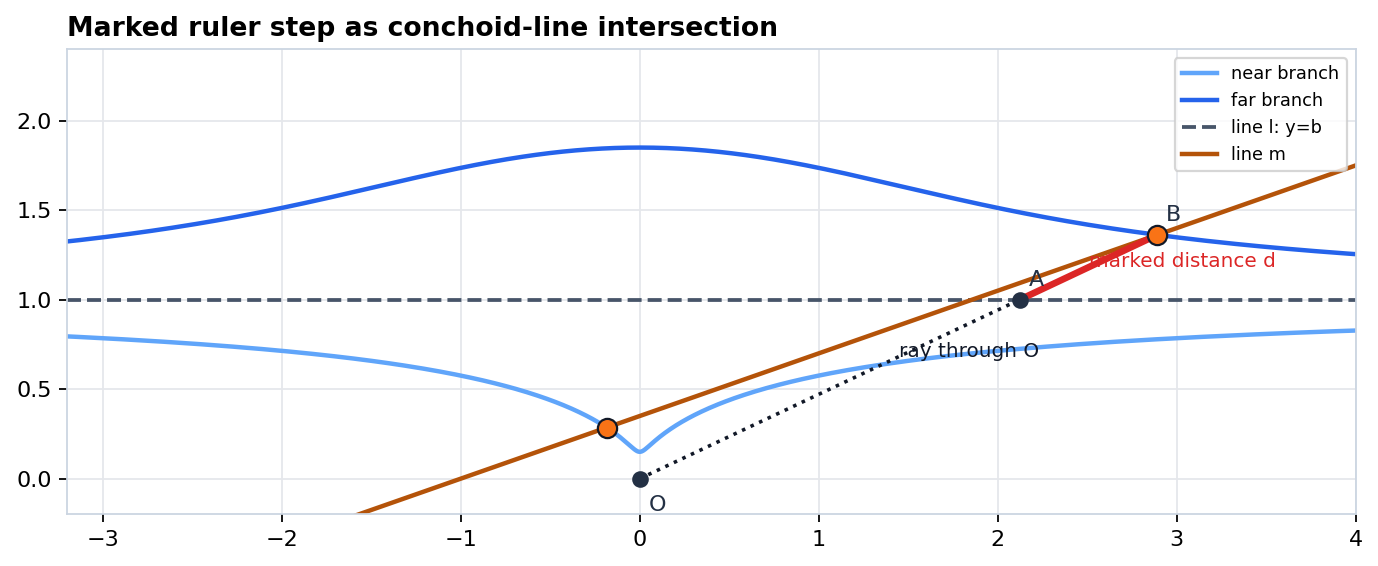

,quantity,value
0,quartic degree after line substitution,4.000000e+00
1,sample conchoid residual,2.220446e-16
2,marked distance residual,4.440892e-16


In [4]:
xs, m_sym, c_sym, b_sym, d_sym = sp.symbols("x m c b d", nonzero=True)
y_line = m_sym * xs + c_sym
conchoid_expression = sp.expand((xs**2 + y_line**2) * (y_line - b_sym) ** 2 - d_sym**2 * y_line**2)
conchoid_quartic_degree = sp.Poly(conchoid_expression, xs).degree()

b_value, d_value, m_value, c_value = 1.0, 0.85, 0.35, 0.35
numeric_poly = sp.Poly(conchoid_expression.subs({b_sym: b_value, d_sym: d_value, m_sym: m_value, c_sym: c_value}), xs)
real_intersections = []
for root in sp.nroots(numeric_poly):
    root_complex = complex(root)
    if abs(root_complex.imag) < 1e-9:
        xx = float(root_complex.real)
        real_intersections.append((xx, m_value * xx + c_value))
B = np.array(max(real_intersections, key=lambda point: point[0]), dtype=float)
A = (b_value / B[1]) * B
O = np.array([0.0, 0.0])
marked_distance = float(np.linalg.norm(B - A))
conchoid_residual = float(abs((B[0] ** 2 + B[1] ** 2) * (B[1] - b_value) ** 2 - d_value**2 * B[1] ** 2))
angle_symbol = sp.symbols("u")
trisection_identity = sp.simplify(sp.expand_trig((2 * sp.cos(angle_symbol)) ** 3 - 3 * (2 * sp.cos(angle_symbol)) - 2 * sp.cos(3 * angle_symbol)))

marked_checks = {
    "conchoid_equation": "(x^2 + y^2)(y - b)^2 = d^2 y^2",
    "line_substitution_degree": int(conchoid_quartic_degree),
    "sample_line": f"y = {m_value}*x + {c_value}",
    "real_intersections": [[float(a), float(b)] for a, b in real_intersections],
    "selected_A_on_y_equals_b": [float(A[0]), float(A[1])],
    "selected_B_on_m": [float(B[0]), float(B[1])],
    "marked_distance": marked_distance,
    "distance_residual": float(abs(marked_distance - d_value)),
    "conchoid_residual": conchoid_residual,
    "trisection_identity_for_x_equals_2cos_u": str(trisection_identity),
}
CHECKS["marked_ruler_conchoid"] = marked_checks
marked_checks_path = remember(save_json(marked_checks, UNIT, "checks", "marked-ruler-conchoid-checks.json", root=ARTIFACT_ROOT))

theta = np.linspace(0.18, np.pi - 0.18, 500)
branches = []
for sign in (-1, 1):
    radius_along_ray = b_value / np.sin(theta) + sign * d_value
    branches.append(np.column_stack([radius_along_ray * np.cos(theta), radius_along_ray * np.sin(theta)]))

fig, ax = plt.subplots(figsize=(8.5, 6.4), constrained_layout=True)
for branch, color, label in zip(branches, ["#60a5fa", "#2563eb"], ["near branch", "far branch"]):
    ax.plot(branch[:, 0], branch[:, 1], color=color, linewidth=2.0, label=label)
xx_plot = np.linspace(-3.2, 4.0, 200)
ax.plot(xx_plot, np.full_like(xx_plot, b_value), color="#475569", linewidth=1.7, linestyle="--", label="line l: y=b")
ax.plot(xx_plot, m_value * xx_plot + c_value, color="#b45309", linewidth=2.0, label="line m")
draw_segment(ax, O, B, color="#111827", linewidth=1.6, linestyle=":", label="ray through O")
draw_segment(ax, A, B, color="#dc2626", linewidth=3.0, label="marked distance d")
label_point(ax, O, "O", offset=(0.05, -0.18))
label_point(ax, A, "A", offset=(0.05, 0.08))
label_point(ax, B, "B", offset=(0.05, 0.08))
ax.scatter([p[0] for p in real_intersections], [p[1] for p in real_intersections], s=75, color="#f97316", edgecolor="#111827", zorder=5)
ax.set_xlim(-3.2, 4.0)
ax.set_ylim(-0.2, 2.4)
style_axis(ax, "Marked ruler step as conchoid-line intersection")
ax.legend(loc="upper right", fontsize=8)
marked_path = remember(save_matplotlib(fig, UNIT, "figures", "marked-ruler-conchoid-neusis.png", root=ARTIFACT_ROOT))
plt.close(fig)

display_artifact(marked_path, width=900)
pd.DataFrame([
    {"quantity": "quartic degree after line substitution", "value": conchoid_quartic_degree},
    {"quantity": "sample conchoid residual", "value": conchoid_residual},
    {"quantity": "marked distance residual", "value": abs(marked_distance - d_value)},
])


The marked ruler does not simply add a convenient drawing habit. It changes the algebraic problem class. A straightedge-compass step reduces to linear and quadratic equations; a marked-ruler step between two lines can require a quartic. That is why the next section can connect the same tool to cubic and quartic equations.


## 4. Cubic And Quartic Equations As Construction Routes

Section 31 is a bridge in both directions. Geometrically, the marked ruler supplies cube roots and trisections. Algebraically, real cubic and quartic equations can be reduced to those operations plus square roots.

For cubics, depress the equation to `x^3 + p*x + q = 0`. Cardano's substitution `x = u + v` works when `u*v = -p/3` and `u^3 + v^3 = -q`. In the casus irreducibilis, the real route is trigonometric: `x = 2*cos(theta/3)` solves `x^3 - 3*x - 2*cos(theta) = 0`, so angle trisection is exactly the missing operation.

For quartics, first remove the cubic term. Descartes's factorization reduces `x^4 + p*x^2 + q*x + r` to a cubic resolvent in `y = a^2`, followed by square roots.


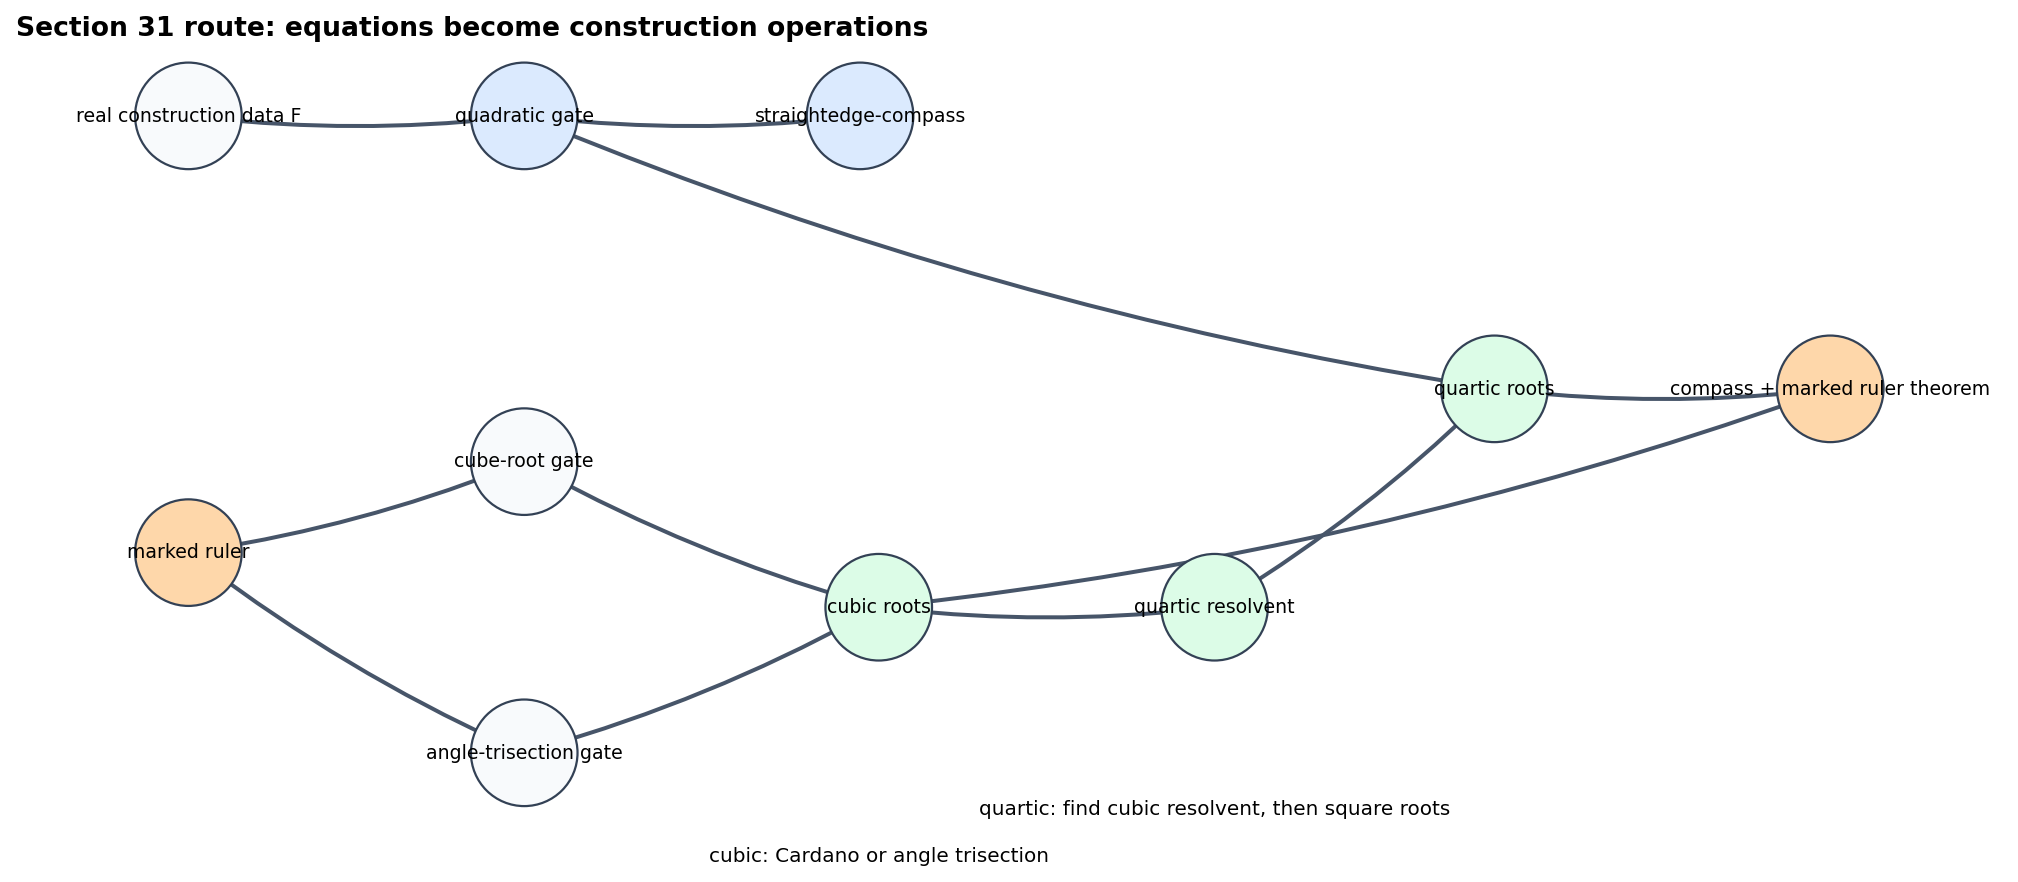

,identity,residual
0,Cardano substitution,0
1,trisection cubic,0
2,quartic resolvent,0


In [5]:
u, v, p, q, r, y = sp.symbols("u v p q r y")
cubic_cardano_identity = sp.expand(((u + v) ** 3 + p * (u + v) + q).subs({p: -3 * u * v, q: -(u**3 + v**3)}))
angle = sp.symbols("angle")
trisection_cubic_identity = sp.simplify(sp.expand_trig((2 * sp.cos(angle)) ** 3 - 3 * (2 * sp.cos(angle)) - 2 * sp.cos(3 * angle)))
quartic_resolvent = y**3 + 2 * p * y**2 + (p**2 - 4 * r) * y - q**2
quartic_resolvent_identity = sp.expand(y * (p + y) ** 2 - q**2 - 4 * r * y - quartic_resolvent)

solver_checks = {
    "cardano_identity_residual": str(cubic_cardano_identity),
    "trisection_cubic_identity_residual": str(trisection_cubic_identity),
    "quartic_resolvent": str(quartic_resolvent),
    "quartic_resolvent_identity_residual": str(quartic_resolvent_identity),
}
CHECKS["cubic_quartic_routes"] = solver_checks
solver_checks_path = remember(save_json(solver_checks, UNIT, "checks", "cubic-quartic-identities.json", root=ARTIFACT_ROOT))

route = nx.DiGraph()
route_edges = [
    ("real construction data F", "quadratic gate"),
    ("quadratic gate", "straightedge-compass"),
    ("marked ruler", "cube-root gate"),
    ("marked ruler", "angle-trisection gate"),
    ("cube-root gate", "cubic roots"),
    ("angle-trisection gate", "cubic roots"),
    ("cubic roots", "quartic resolvent"),
    ("quadratic gate", "quartic roots"),
    ("quartic resolvent", "quartic roots"),
    ("quartic roots", "compass + marked ruler theorem"),
    ("cubic roots", "compass + marked ruler theorem"),
]
route.add_edges_from(route_edges)
route_pos = {
    "real construction data F": (0, 2.0),
    "quadratic gate": (1.8, 2.0),
    "straightedge-compass": (3.6, 2.0),
    "marked ruler": (0, 0.8),
    "cube-root gate": (1.8, 1.05),
    "angle-trisection gate": (1.8, 0.25),
    "cubic roots": (3.7, 0.65),
    "quartic resolvent": (5.5, 0.65),
    "quartic roots": (7.0, 1.25),
    "compass + marked ruler theorem": (8.8, 1.25),
}
fig, ax = plt.subplots(figsize=(12.5, 5.4), constrained_layout=True)
node_colors = []
for node in route.nodes:
    if "marked" in node:
        node_colors.append("#fed7aa")
    elif "quadratic" in node or "straightedge" in node:
        node_colors.append("#dbeafe")
    elif "cubic" in node or "quartic" in node:
        node_colors.append("#dcfce7")
    else:
        node_colors.append("#f8fafc")
nx.draw_networkx_nodes(route, route_pos, ax=ax, node_color=node_colors, edgecolors="#334155", node_size=2300)
nx.draw_networkx_labels(route, route_pos, ax=ax, font_size=8.5)
nx.draw_networkx_edges(route, route_pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.8, edge_color="#475569", connectionstyle="arc3,rad=0.06")
ax.text(5.5, 0.08, "quartic: find cubic resolvent, then square roots", ha="center", fontsize=9)
ax.text(3.7, -0.05, "cubic: Cardano or angle trisection", ha="center", fontsize=9)
ax.set_title("Section 31 route: equations become construction operations", loc="left", fontsize=12, weight="bold")
ax.axis("off")
route_path = remember(save_matplotlib(fig, UNIT, "figures", "cubic-quartic-solver-route.png", root=ARTIFACT_ROOT))
plt.close(fig)

display_artifact(route_path, width=980)
pd.DataFrame([
    {"identity": "Cardano substitution", "residual": cubic_cardano_identity},
    {"identity": "trisection cubic", "residual": trisection_cubic_identity},
    {"identity": "quartic resolvent", "residual": quartic_resolvent_identity},
])


The route graph explains the chapter's equivalence theorem in computational language. If a real number can be reached by the listed square-root, cube-root, and trisection gates, it can be constructed with compass and marked ruler. Conversely, the marked-ruler operation between two lines can be encoded by a quartic, so the geometry does not exceed the algebraic route shown here.


## 5. Finite Extensions And Constructible Degree Checks

Section 32 supplies the algebraic bookkeeping used throughout the chapter. The central rule is multiplicativity: if `F <= E <= G`, then `deg(G/F) = deg(G/E) * deg(E/F)`. This is the reason a tower of quadratic extensions has 2-power degree, and it is also why marked-ruler towers have degree of the form `2^a * 3^b`.

The sharper warning is that field degree alone can lie. A quartic root has degree 4, but it need not be straightedge-compass constructible unless the Galois group of its minimal polynomial has 2-power order. The table includes the quartic from the source discussion as the degree-only trap: degree 4 passes the naive test, while Galois order 24 fails the compass-only test and fits the marked-ruler class.


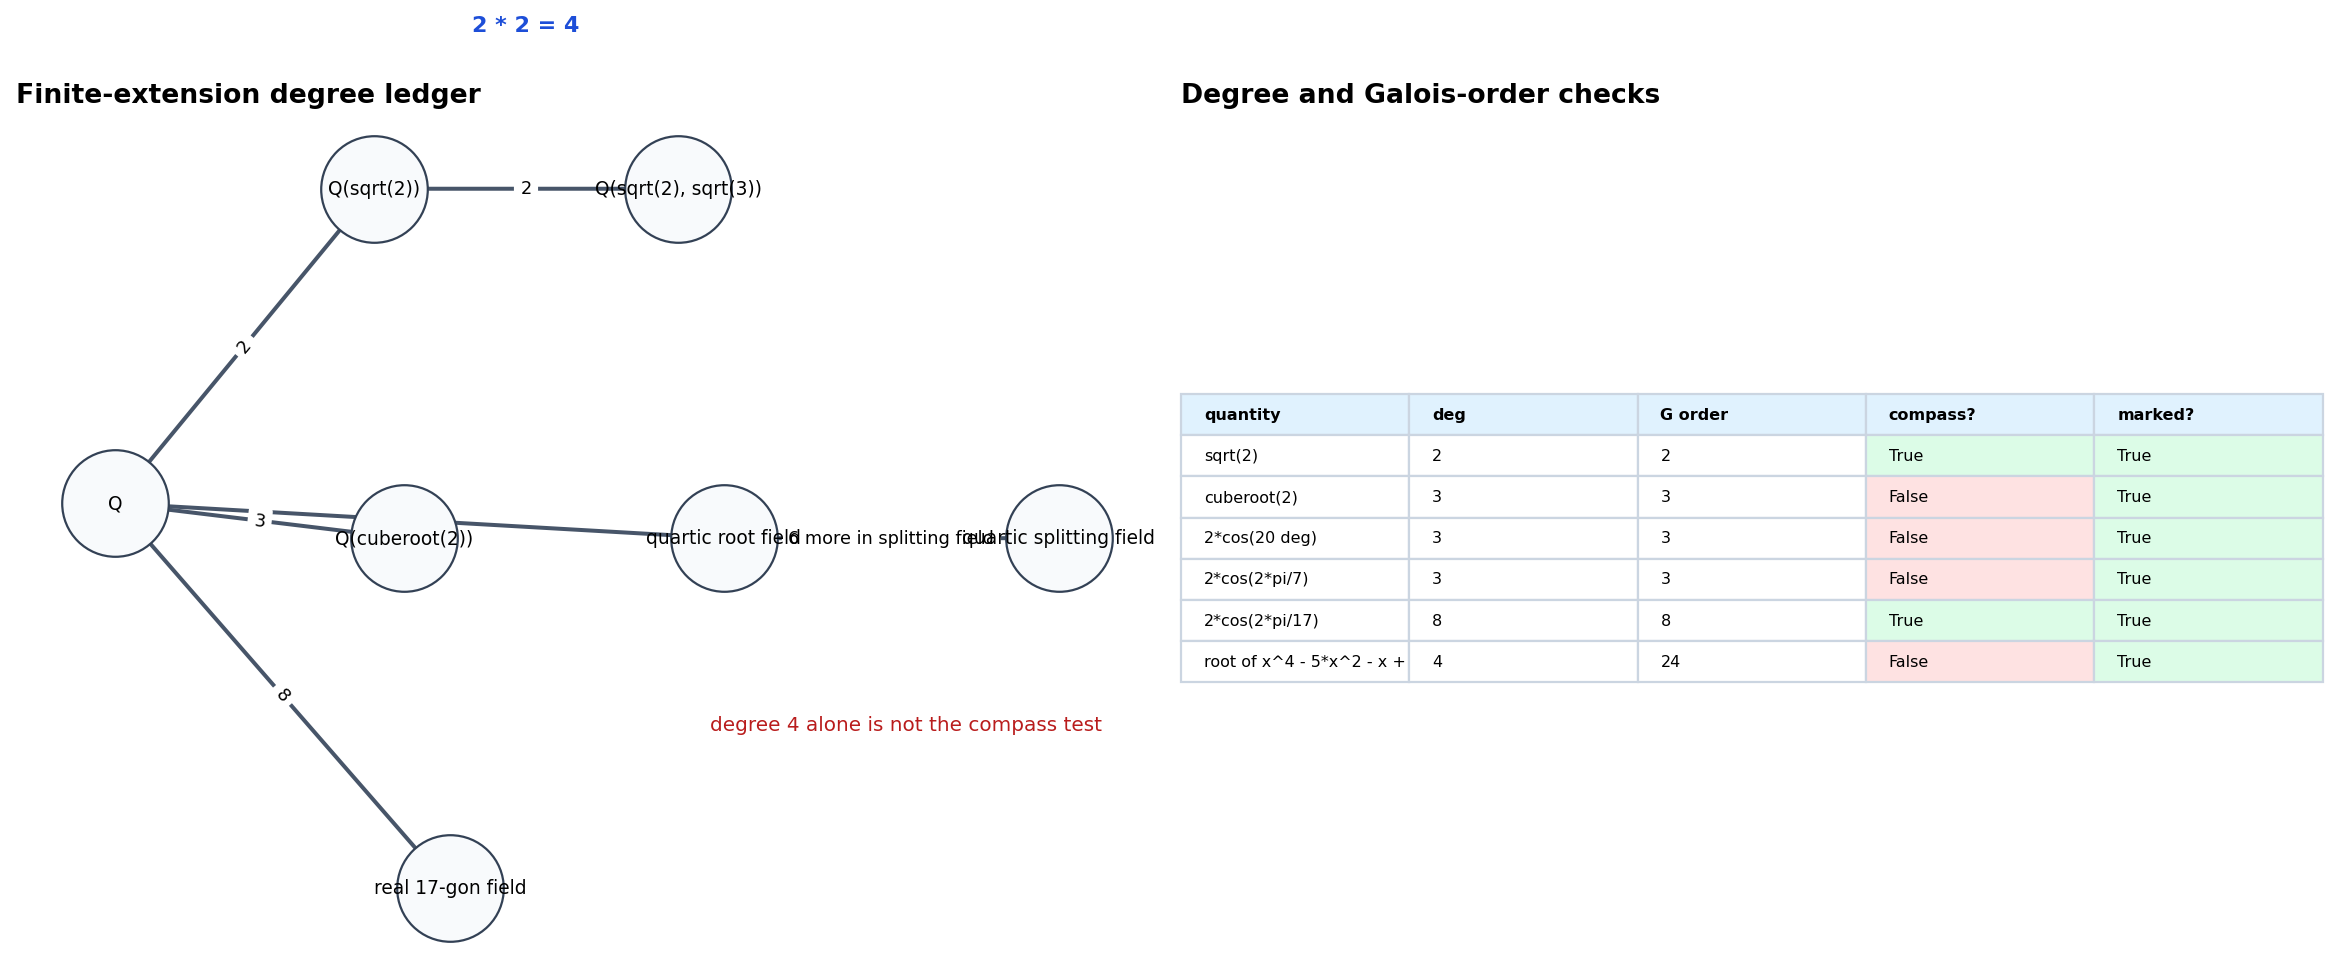

,quantity,minimal_polynomial,degree,degree_power_of_2,degree_2_3_only,galois_order_used_for_test,galois_order_power_of_2,galois_order_2_3_only,note
0,sqrt(2),x**2 - 2,2,True,True,2,True,True,ordinary square-root gate
1,cuberoot(2),x**3 - 2,3,False,True,3,False,True,duplicate-cube coordinate
2,2*cos(20 deg),x**3 - 3*x - 1,3,False,True,3,False,True,trisecting 60 degrees
3,2*cos(2*pi/7),x**3 + x**2 - 2*x - 1,3,False,True,3,False,True,regular heptagon signal
4,2*cos(2*pi/17),x**8 + x**7 - 7*x**6 - 6*x**5 + 15*x**4 + 10*x...,8,True,True,8,True,True,regular 17-gon signal
5,root of x^4 - 5*x^2 - x + 1,x**4 - 5*x**2 - x + 1,4,True,True,24,False,True,degree-only trap from the chapter


In [6]:
sqrt2_poly = sp.Poly(sp.minpoly(sp.sqrt(2), x), x)
cuberoot2_poly = sp.Poly(sp.minpoly(sp.real_root(2, 3), x), x)
cos20_double_poly = sp.Poly(sp.minpoly(2 * sp.cos(sp.pi / 9), x), x)
heptagon_poly = sp.Poly(sp.minpoly(2 * sp.cos(2 * sp.pi / 7), x), x)
seventeen_poly = alpha_minpoly
bad_quartic_poly = sp.Poly(x**4 - 5 * x**2 - x + 1, x, domain=sp.QQ)
bad_quartic_group, _ = galois_group(bad_quartic_poly)
bad_quartic_galois_order = int(bad_quartic_group.order())

candidate_rows = []
for name, poly, note, galois_order in [
    ("sqrt(2)", sqrt2_poly, "ordinary square-root gate", 2),
    ("cuberoot(2)", cuberoot2_poly, "duplicate-cube coordinate", 3),
    ("2*cos(20 deg)", cos20_double_poly, "trisecting 60 degrees", 3),
    ("2*cos(2*pi/7)", heptagon_poly, "regular heptagon signal", 3),
    ("2*cos(2*pi/17)", seventeen_poly, "regular 17-gon signal", 8),
    ("root of x^4 - 5*x^2 - x + 1", bad_quartic_poly, "degree-only trap from the chapter", bad_quartic_galois_order),
]:
    degree = int(poly.degree())
    candidate_rows.append({
        "quantity": name,
        "minimal_polynomial": str(poly.as_expr()),
        "degree": degree,
        "degree_power_of_2": is_power_of(degree, {2}),
        "degree_2_3_only": is_power_of(degree, {2, 3}),
        "galois_order_used_for_test": galois_order,
        "galois_order_power_of_2": is_power_of(int(galois_order), {2}),
        "galois_order_2_3_only": is_power_of(int(galois_order), {2, 3}),
        "note": note,
    })
constructibility_candidates = pd.DataFrame(candidate_rows)
constructibility_table_path = write_table(constructibility_candidates, "constructibility-candidates.csv")

extension_checks = {
    "degree_Q_sqrt2_over_Q": sqrt2_poly.degree(),
    "degree_Q_sqrt2_sqrt3_over_Q": 4,
    "degree_multiplication_2_times_2": 2 * 2,
    "bad_quartic_irreducible": bool(bad_quartic_poly.is_irreducible),
    "bad_quartic_real_root_count": int(sum(abs(complex(root).imag) < 1e-9 for root in sp.nroots(bad_quartic_poly))),
    "bad_quartic_galois_order": bad_quartic_galois_order,
    "bad_quartic_compass_test": is_power_of(bad_quartic_galois_order, {2}),
    "bad_quartic_marked_ruler_test": is_power_of(bad_quartic_galois_order, {2, 3}),
}
CHECKS["finite_extensions"] = extension_checks
extension_checks_path = remember(save_json(extension_checks, UNIT, "checks", "field-extension-degree-checks.json", root=ARTIFACT_ROOT))

field_graph = nx.DiGraph()
field_edges = [
    ("Q", "Q(sqrt(2))", "2"),
    ("Q(sqrt(2))", "Q(sqrt(2), sqrt(3))", "2"),
    ("Q", "Q(cuberoot(2))", "3"),
    ("Q", "real 17-gon field", "8"),
    ("Q", "quartic root field", "4"),
    ("quartic root field", "quartic splitting field", "6 more in splitting field"),
]
field_graph.add_edges_from((u, v) for u, v, _ in field_edges)
field_pos = {
    "Q": (0, 1.2),
    "Q(sqrt(2))": (1.7, 2.1),
    "Q(sqrt(2), sqrt(3))": (3.7, 2.1),
    "Q(cuberoot(2))": (1.9, 1.1),
    "real 17-gon field": (2.2, 0.1),
    "quartic root field": (4.0, 1.1),
    "quartic splitting field": (6.2, 1.1),
}
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6), constrained_layout=True)
ax = axes[0]
nx.draw_networkx_nodes(field_graph, field_pos, ax=ax, node_color="#f8fafc", edgecolors="#334155", node_size=2300)
nx.draw_networkx_labels(field_graph, field_pos, ax=ax, font_size=8.4)
nx.draw_networkx_edges(field_graph, field_pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.8, edge_color="#475569")
nx.draw_networkx_edge_labels(field_graph, field_pos, edge_labels={(u, v): label for u, v, label in field_edges}, ax=ax, font_size=8)
ax.text(2.7, 2.55, "2 * 2 = 4", ha="center", fontsize=10, weight="bold", color="#1d4ed8")
ax.text(5.2, 0.55, "degree 4 alone is not the compass test", ha="center", fontsize=9, color="#b91c1c")
ax.set_title("Finite-extension degree ledger", loc="left", fontsize=12, weight="bold")
ax.axis("off")

ax = axes[1]
ax.axis("off")
display_cols = ["quantity", "degree", "galois_order_used_for_test", "galois_order_power_of_2", "galois_order_2_3_only"]
cell_text = constructibility_candidates[display_cols].values.tolist()
table = ax.table(cellText=cell_text, colLabels=["quantity", "deg", "G order", "compass?", "marked?"], cellLoc="left", colLoc="left", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(7.2)
table.scale(1, 1.35)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#cbd5e1")
    if row == 0:
        cell.set_facecolor("#e0f2fe")
        cell.set_text_props(weight="bold")
    elif col in (3, 4):
        value = str(cell.get_text().get_text())
        cell.set_facecolor("#dcfce7" if value == "True" else "#fee2e2")
ax.set_title("Degree and Galois-order checks", loc="left", fontsize=12, weight="bold")

extension_path = remember(save_matplotlib(fig, UNIT, "figures", "finite-extension-degree-ledger.png", root=ARTIFACT_ROOT))
plt.close(fig)

display_artifact(extension_path, width=980)
constructibility_candidates


The last row is the warning from Section 28 made computational. A degree-4 root looks compatible with a quadratic tower if one only checks `deg Q(alpha)/Q`. The splitting field reveals the failure: its Galois group has order 24, not a power of 2. Marked-ruler constructibility uses the broader `2^a*3^b` test, so the same example lands on the other side of the enlarged-tool boundary.


## Applied Lab: Filter Regular Polygons By The Allowed Degree Primes

The lab turns Theorems 29.4 and 31.9 into an experiment. For regular polygons, the relevant cyclotomic Galois group has order `phi(n)`. Compass-straightedge construction requires only the prime 2 in `phi(n)`. Compass plus marked ruler permits primes 2 and 3.

Move through the HTML scatter by hovering over `n`. Points in blue are compass-constructible. Orange points are not compass-constructible but pass the marked-ruler degree-prime test. Gray points fail even the marked-ruler filter.


In [7]:
def polygon_lab_row(n_value: int) -> dict[str, object]:
    phi = int(sp.totient(n_value))
    compass = is_power_of(phi, {2})
    marked = is_power_of(phi, {2, 3})
    return {
        "n": n_value,
        "phi_n": phi,
        "compass_constructible": compass,
        "marked_ruler_constructible": marked,
        "marked_only": marked and not compass,
        "phi_prime_factors": "*".join(str(p) for p in sorted(sp.factorint(phi))) or "1",
    }

regular_lab = pd.DataFrame([polygon_lab_row(n_value) for n_value in range(3, 91)])
regular_lab_path = write_table(regular_lab, "regular-ngon-degree-lab.csv")
regular_lab["class"] = np.select(
    [regular_lab["compass_constructible"], regular_lab["marked_only"]],
    ["compass", "marked only"],
    default="not by these tests",
)
color_map = {"compass": "#2563eb", "marked only": "#f97316", "not by these tests": "#94a3b8"}
fig = go.Figure()
for class_name, group in regular_lab.groupby("class"):
    fig.add_trace(go.Scatter(
        x=group["n"],
        y=group["phi_n"],
        mode="markers",
        marker={"size": 10, "color": color_map[class_name], "line": {"width": 0.7, "color": "#111827"}},
        name=class_name,
        customdata=np.stack([group["phi_prime_factors"], group["marked_only"]], axis=-1),
        hovertemplate="n=%{x}<br>phi(n)=%{y}<br>phi factors=%{customdata[0]}<br>marked only=%{customdata[1]}<extra></extra>",
    ))
fig.update_layout(
    title="Regular polygon constructibility filter up to n=90",
    xaxis_title="number of sides n",
    yaxis_title="Euler phi(n), log scale",
    yaxis_type="log",
    template="plotly_white",
    legend_title="degree-prime class",
    height=560,
)
regular_lab_html = remember(save_plotly_html(fig, UNIT, "interactive", "regular-ngon-constructibility-filter.html", root=ARTIFACT_ROOT))

lab_checks = {
    "n_17_compass_constructible": bool(regular_lab.loc[regular_lab["n"] == 17, "compass_constructible"].iloc[0]),
    "n_7_marked_only": bool(regular_lab.loc[regular_lab["n"] == 7, "marked_only"].iloc[0]),
    "n_9_marked_ruler_constructible": bool(regular_lab.loc[regular_lab["n"] == 9, "marked_ruler_constructible"].iloc[0]),
    "marked_only_values_up_to_30": regular_lab.loc[regular_lab["marked_only"] & (regular_lab["n"] <= 30), "n"].astype(int).tolist(),
    "compass_values_up_to_34": regular_lab.loc[regular_lab["compass_constructible"] & (regular_lab["n"] <= 34), "n"].astype(int).tolist(),
}
CHECKS["regular_polygon_lab"] = lab_checks
lab_checks_path = remember(save_json(lab_checks, UNIT, "checks", "regular-polygon-lab-checks.json", root=ARTIFACT_ROOT))

display_artifact(regular_lab_html, width="100%", height=620)
regular_lab.head(16)


,n,phi_n,compass_constructible,marked_ruler_constructible,marked_only,phi_prime_factors,class
0,3,2,True,True,False,2,compass
1,4,2,True,True,False,2,compass
2,5,4,True,True,False,2,compass
3,6,2,True,True,False,2,compass
4,7,6,False,True,True,2*3,marked only
5,8,4,True,True,False,2,compass
6,9,6,False,True,True,2*3,marked only
7,10,4,True,True,False,2,compass
8,11,10,False,False,False,2*5,not by these tests
9,12,4,True,True,False,2,compass


This lab is deliberately a filter rather than a construction recipe. For regular polygons, the filter is exact because the roots-of-unity Galois groups are abelian and controlled by `phi(n)`. For arbitrary algebraic numbers, the previous section's Galois-order warning still applies.


## Final Sanity Checks

The final cell asserts the notebook's central invariants and records book-local artifact paths. These checks are part of the lesson: the construction claims are not just illustrated, they leave a reproducible algebraic or geometric residue.


In [8]:
def min_bytes_for(path: Path) -> int:
    if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".html", ".htm"}:
        return 512
    return 128


artifact_paths = [assert_artifact(path, min_bytes=min_bytes_for(path)) for path in ARTIFACTS]

assert construction_checks["cube_poly_irreducible"]
assert construction_checks["trisection_poly_irreducible"]
assert construction_checks["cube_degree"] == 3
assert construction_checks["trisection_degree"] == 3
assert construction_checks["degree_3_is_power_of_2"] is False
assert construction_checks["pi_transcendental_known_to_sympy"] is True

assert seventeen_checks["degree_alpha"] == 8
assert seventeen_checks["degree_alpha_is_power_of_2"] is True
assert seventeen_checks["side_length_spread"] < 1e-12
assert seventeen_checks["gamma_residual"] < 1e-12
assert seventeen_checks["beta_plus_beta_prime_residual"] < 1e-12
assert seventeen_checks["beta_times_beta_prime_plus_1_residual"] < 1e-12

assert marked_checks["line_substitution_degree"] == 4
assert marked_checks["distance_residual"] < 1e-10
assert marked_checks["conchoid_residual"] < 1e-10

assert solver_checks["cardano_identity_residual"] == "0"
assert solver_checks["trisection_cubic_identity_residual"] == "0"
assert solver_checks["quartic_resolvent_identity_residual"] == "0"

assert extension_checks["degree_Q_sqrt2_sqrt3_over_Q"] == extension_checks["degree_multiplication_2_times_2"] == 4
assert extension_checks["bad_quartic_irreducible"]
assert extension_checks["bad_quartic_galois_order"] == 24
assert extension_checks["bad_quartic_compass_test"] is False
assert extension_checks["bad_quartic_marked_ruler_test"] is True

assert lab_checks["n_17_compass_constructible"] is True
assert lab_checks["n_7_marked_only"] is True
assert lab_checks["n_9_marked_ruler_constructible"] is True

visual_summary = {
    "unit": UNIT,
    "artifact_count": len(artifact_paths),
    "artifacts": [book_relative(path) for path in artifact_paths],
    "figure_count": sum(1 for path in artifact_paths if path.suffix.lower() in {".png", ".svg", ".jpg", ".jpeg"}),
    "interactive_count": sum(1 for path in artifact_paths if path.suffix.lower() in {".html", ".htm"}),
    "table_count": sum(1 for path in artifact_paths if path.suffix.lower() == ".csv"),
    "check_count": sum(1 for path in artifact_paths if path.suffix.lower() == ".json"),
    "core_checks": {
        "cube_degree": construction_checks["cube_degree"],
        "trisection_degree": construction_checks["trisection_degree"],
        "regular_17_minpoly_degree": seventeen_checks["degree_alpha"],
        "conchoid_line_degree": marked_checks["line_substitution_degree"],
        "bad_quartic_galois_order": extension_checks["bad_quartic_galois_order"],
    },
}
visual_checks_path = remember(save_json(visual_summary, UNIT, "checks", "visual-checks.json", root=ARTIFACT_ROOT))
assert_artifact(visual_checks_path, min_bytes=512)

final_sanity = {
    "unit": UNIT,
    "source_span": "printed pp. 241-294 / PDF pp. 253-306; Sections 28-32",
    "artifact_count_before_summary_file": len(artifact_paths),
    "artifact_count_including_summary_file": len(ARTIFACTS),
    "visual_checks": book_relative(visual_checks_path),
    "checks": CHECKS,
}
notebook_sanity_path = remember(save_json(final_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT))
assert_artifact(notebook_sanity_path, min_bytes=512)

pd.DataFrame([
    {"check": "artifacts before summary", "value": len(artifact_paths)},
    {"check": "regular 17-gon minpoly degree", "value": seventeen_checks["degree_alpha"]},
    {"check": "conchoid line-intersection degree", "value": marked_checks["line_substitution_degree"]},
    {"check": "bad quartic Galois order", "value": extension_checks["bad_quartic_galois_order"]},
])


,check,value
0,artifacts before summary,15
1,regular 17-gon minpoly degree,8
2,conchoid line-intersection degree,4
3,bad quartic Galois order,24


## Takeaways

- Straightedge-compass constructions are controlled by quadratic extension towers; this blocks cube duplication and a general angle trisection, while circle squaring needs the stronger fact that `pi` is transcendental.
- The regular 17-gon is the chapter's positive signal: the needed real root-of-unity coordinate has degree 8 and can be reached through nested quadratic period sums.
- A marked ruler changes the algebra. A neusis step hides a conchoid, and conchoid-line intersection is quartic.
- Real cubic and quartic equations match the marked-ruler toolkit: square roots, cube roots, angle trisection, and the quartic cubic resolvent.
- Finite-extension degree is the first diagnostic, not the last. Galois order is the sharper constructibility test, and regular polygons are the clean case where the `phi(n)` filter is exact.
